1.6646155286060689


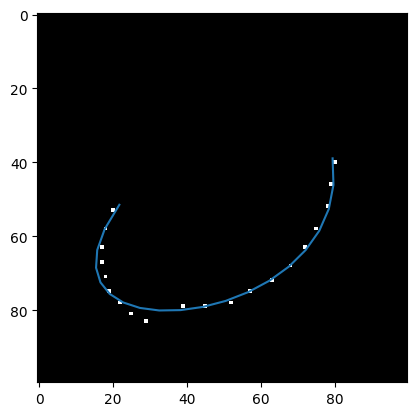

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from bez.bezier import interpolate_bezier, fit_bezier, std_distance

# %%
image = np.zeros((100, 100))
t = np.linspace(0, 3, 20)
traj_x = np.where(
    t < 1.6, (40 * (np.cos(t) + 1)), 40 * (np.cos(t + 0.3) + 1) + 10 * (t - 1)
).astype(int)
traj_y = np.where(
    t < 1.6, (40 * (np.sin(t) + 1)), 40 * (np.sin(t + 0.3) + 1) + 10 * (t - 1)
).astype(int)
image[traj_y, traj_x] = 1
plt.imshow(image, cmap="gray")

# %%
traj_fit = interpolate_bezier(fit_bezier((traj_x, traj_y), t), t)
x, y = traj_fit
plt.imshow(image, cmap="gray")
plt.plot(x, y)

print(std_distance(traj_fit, (traj_x, traj_y)))

In [5]:
def fit_bezier_error(pixel_c : np.array):
    traj = np.vstack((pixel_c[:, 0], pixel_c[:, 1]))
    instants = np.linspace(0, 1, traj.shape[1])
    
    control_points = fit_bezier(traj,instants)
    traj_fit = interpolate_bezier(control_points, instants)

    error = std_distance(traj_fit, traj)

    return control_points, error



In [7]:
traj = np.array([traj_x, traj_y])
print(fit_bezier_error(traj.T))

(array([[ 79.38475438,  86.04546882, -17.0556012 ,  21.6879729 ],
       [ 38.91372106,  86.45120465,  78.63879472,  51.47329193]]), np.float64(1.6646155286060416))
